In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# ── Reuse exactly your existing data loading ──
df_all = pd.read_csv('Full_Dataset.csv', header=0)
df_all.rename(columns={'Date': 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

df_all = df_all.groupby(level=0).mean()
data = df_all[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].resample('1h').mean().ffill()
data.columns = ['belpex', 'solar', 'wind', 'load']

In [4]:
result = adfuller(data['belpex'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.4f}")

if result[1] < 0.05:
    print("→ Series is STATIONARY → use d=0")
else:
    print("→ Series is NON-STATIONARY → use d=1")

ADF Statistic: -7.3071
p-value:       0.0000
→ Series is STATIONARY → use d=0


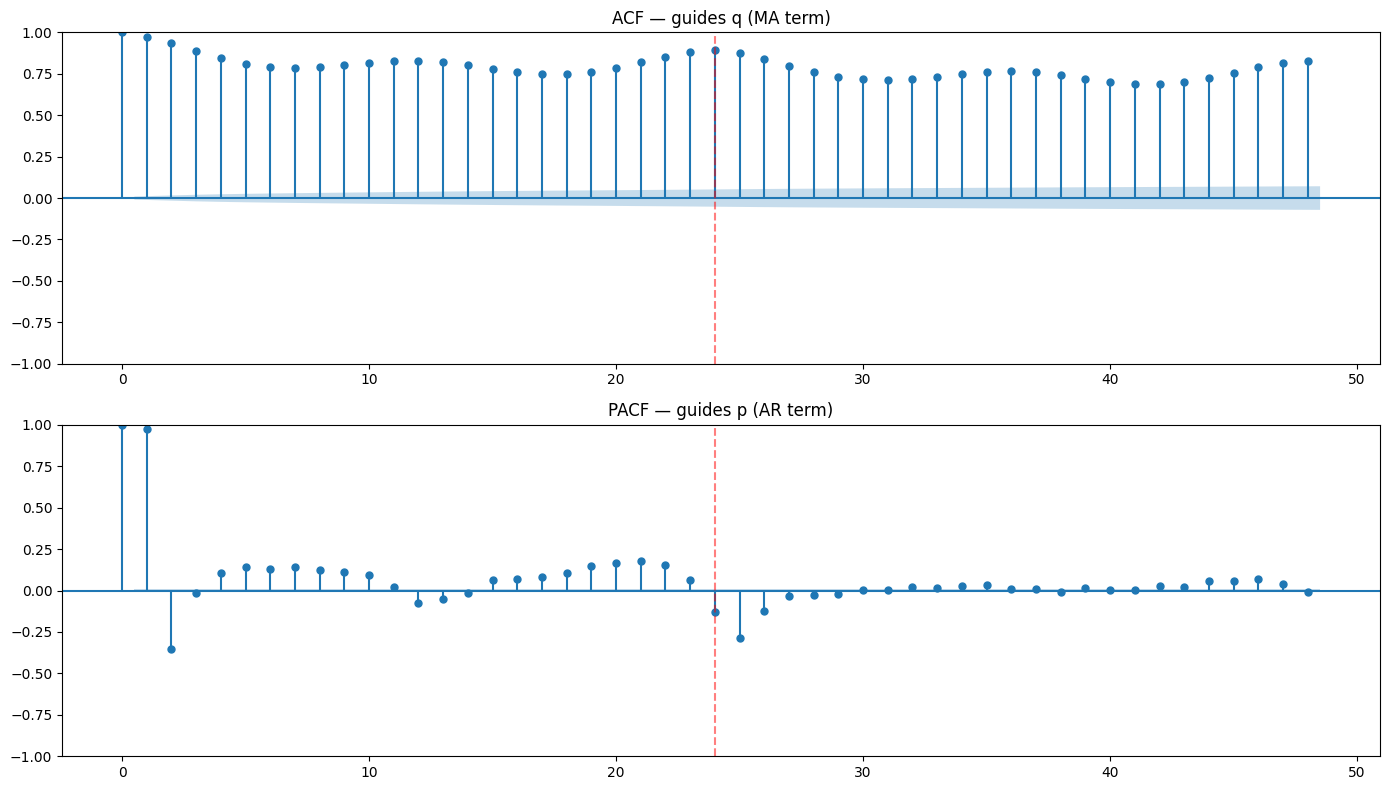

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(data['belpex'], lags=48, ax=axes[0])
axes[0].set_title('ACF — guides q (MA term)')
axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.5, label='lag 24')

plot_pacf(data['belpex'], lags=48, ax=axes[1])
axes[1].set_title('PACF — guides p (AR term)')
axes[1].axvline(x=24, color='red', linestyle='--', alpha=0.5, label='lag 24')

plt.tight_layout()
plt.show()

In [6]:
# Use same 85/15 split as your ANN
split_idx = int(len(data) * 0.85)

train = data.iloc[:split_idx]
test  = data.iloc[split_idx:]

# Separate target and exogenous variables
y_train = train['belpex']
y_test  = test['belpex']

exog_train = train[['solar', 'wind', 'load']]
exog_test  = test[['solar', 'wind', 'load']]

print(f"Training samples: {len(train)}")
print(f"Test samples:     {len(test)}")

Training samples: 38391
Test samples:     6776


In [ ]:
from pmdarima import auto_arima

print("Running auto_arima... (this may take a few minutes)")

auto_model = auto_arima(
    y_train,
    exogenous=exog_train,
    seasonal=True,
    m=24,                    # daily seasonality
    d=None,                  # auto-detect differencing
    D=None,                  # auto-detect seasonal differencing
    stepwise=True,           # faster search
    information_criterion='aic',
    trace=True,              # prints each model being tested
    error_action='ignore',
    suppress_warnings=True
)

Running auto_arima... (this may take a few minutes)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=157.79 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=350270.212, Time=0.40 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=338227.515, Time=26.07 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=341474.085, Time=27.33 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=350268.212, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=345997.902, Time=0.50 sec
 ARIMA(1,1,0)(2,0,0)[24] intercept   : AIC=335721.611, Time=151.08 sec
 ARIMA(1,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=243.71 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=48.39 sec
 ARIMA(0,1,0)(2,0,0)[24] intercept   : AIC=335771.659, Time=84.36 sec


MemoryError: Unable to allocate 762. MiB for an array with shape (51, 51, 38392) and data type float64

In [8]:
print("\nBest model found:")
print(auto_model.summary())
print(f"\nBest order: {auto_model.order}")
print(f"Best seasonal order: {auto_model.seasonal_order}")


Best model found:


NameError: name 'auto_model' is not defined

In [9]:
auto_model = auto_arima(
    y_train,
    exogenous=exog_train,
    seasonal=True, m=24,
    d=0,           # ← fix this based on ADF result
    D=0,           # ← already confirmed from previous run
    max_p=2,
    max_q=2,
    max_P=2,
    max_Q=1,
    stepwise=True,
    information_criterion='aic',
    trace=True,
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=203.03 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=466309.420, Time=0.44 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=337380.716, Time=42.18 sec


MemoryError: Unable to allocate 198. MiB for an array with shape (26, 26, 38391) and data type float64

In [11]:
model = SARIMAX(
    endog=y_train,
    exog=exog_train,
    order=(0, 1, 0),
    seasonal_order=(2, 0, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted = model.fit(disp=False)
print(fitted.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             belpex   No. Observations:                38391
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 24)   Log Likelihood             -165200.219
Date:                            Fri, 01 May 2026   AIC                         330412.437
Time:                                    16:30:38   BIC                         330463.763
Sample:                                01-01-2021   HQIC                        330428.715
                                     - 05-19-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
solar         -0.0218      0.000    -60.013      0.000      -0.023      -0.021
wind          -0.0111      0.001   

In [12]:
model_2 = SARIMAX(
    endog=y_train,
    exog=exog_train,
    order=(0, 1, 1),
    seasonal_order=(2, 0, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted = model.fit(disp=False)
print(fitted.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             belpex   No. Observations:                38391
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 24)   Log Likelihood             -165200.219
Date:                            Fri, 01 May 2026   AIC                         330412.437
Time:                                    16:40:58   BIC                         330463.763
Sample:                                01-01-2021   HQIC                        330428.715
                                     - 05-19-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
solar         -0.0218      0.000    -60.013      0.000      -0.023      -0.021
wind          -0.0111      0.001   